Pandas script to calculate Total spending per customer and Top product (by total sales) in each category

In [1]:
import pandas as pd
from io import StringIO

data = """Customer,Product,Category,Amount
Alice,Laptop,Electronics,1200
Bob,Mouse,Electronics,25
Alice,Keyboard,Electronics,70
Charlie,Shirt,Clothing,40
Bob,Tablet,Electronics,500
Alice,Shirt,Clothing,60
"""

# Using StringIO to simulate a file-like object
df = pd.read_csv(StringIO(data))
print(df)

  Customer   Product     Category  Amount
0    Alice    Laptop  Electronics    1200
1      Bob     Mouse  Electronics      25
2    Alice  Keyboard  Electronics      70
3  Charlie     Shirt     Clothing      40
4      Bob    Tablet  Electronics     500
5    Alice     Shirt     Clothing      60


In [20]:
df['total_spending'] = df.groupby('Customer')['Amount'].transform('sum')
result = df[['Customer', 'total_spending']].drop_duplicates()
print(result)

result.to_csv('totals.csv', index=False)

  Customer  total_spending
0    Alice            1330
1      Bob             525
3  Charlie              40


In [21]:
idx = df.groupby('Category')['Amount'].idxmax()
top_products = df.loc[idx, ['Category', 'Product', 'Amount']]
top_products = top_products.rename(columns={'Amount': 'Total_Sales'}).set_index('Category')
print(top_products)

top_products.to_csv('top_products.csv', index=False)

            Product  Total_Sales
Category                        
Clothing      Shirt           60
Electronics  Laptop         1200


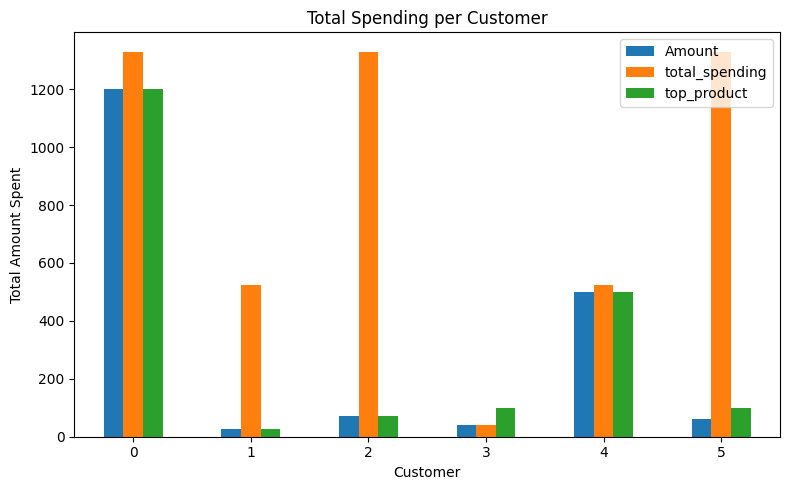

In [25]:
import matplotlib.pyplot as plt

df.plot(kind='bar', figsize=(8, 5), rot=0)
plt.title('Total Spending per Customer')
plt.ylabel('Total Amount Spent')
plt.xlabel('Customer')
plt.tight_layout()
plt.show()